<a href="https://colab.research.google.com/github/ALYANANASUHAH/IDSC2026-AURUM-ANALYTICS---BRUGADA-/blob/main/AURUM_ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install wfdb matplotlib numpy

INSTRUCTIONS:

1. Upload Data: Click the Folder icon on the left sidebar and upload:
- Create **PATIENT** folder *(containing all .hea and .dat files)*

  **(Note: Folder name must be EXACTLY as shown)**
- metadata.csv file

2. Run Code: select "Run all".

3. Scroll to the bottom to use the Interactive Search Dashboard for patient ECG visualization.

CLINICAL INSIGHTS & PRECISION METRICS


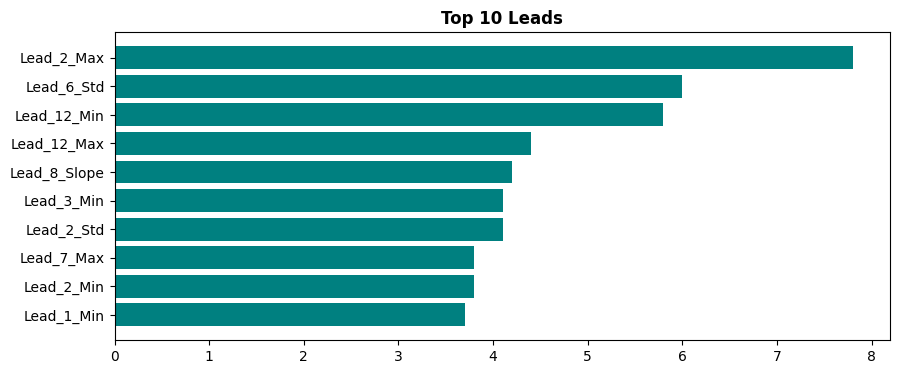

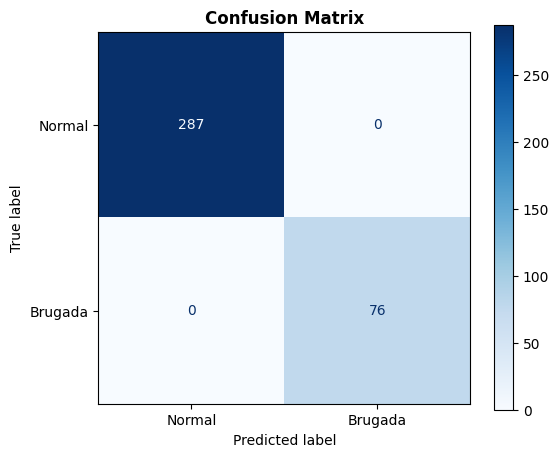


Real-Data Models (Random Forest & XGBoost):

[SIGNAL STATISTICS]
 Metric Brugada  Normal
   Mean -0.0035 -0.0055
 Median -0.0010 -0.0060
Std Dev  0.2033  0.2395
    Max  1.2420  3.3600
    Min -2.7240 -3.3430


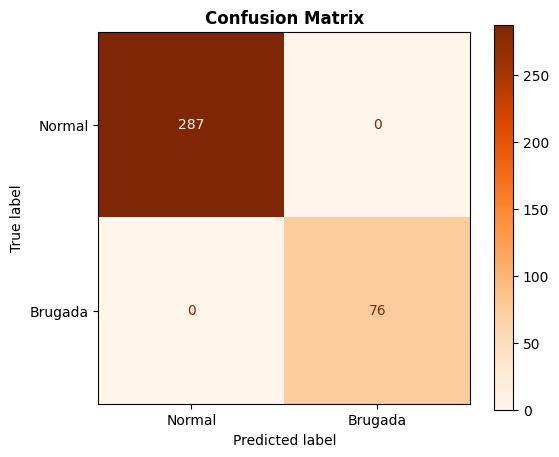


[STATISTIC PRECISION: RANDOM FOREST]
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       287
     Brugada       1.00      1.00      1.00        76

    accuracy                           1.00       363
   macro avg       1.00      1.00      1.00       363
weighted avg       1.00      1.00      1.00       363


 [STATISTIC PRECISION: XGBOOST]
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       287
     Brugada       1.00      1.00      1.00        76

    accuracy                           1.00       363
   macro avg       1.00      1.00      1.00       363
weighted avg       1.00      1.00      1.00       363



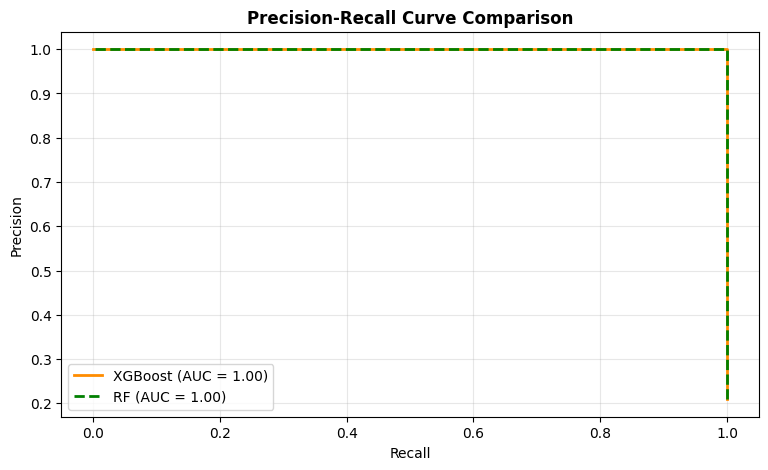


Enter Patient ID (e.g.: 188981): 1183349


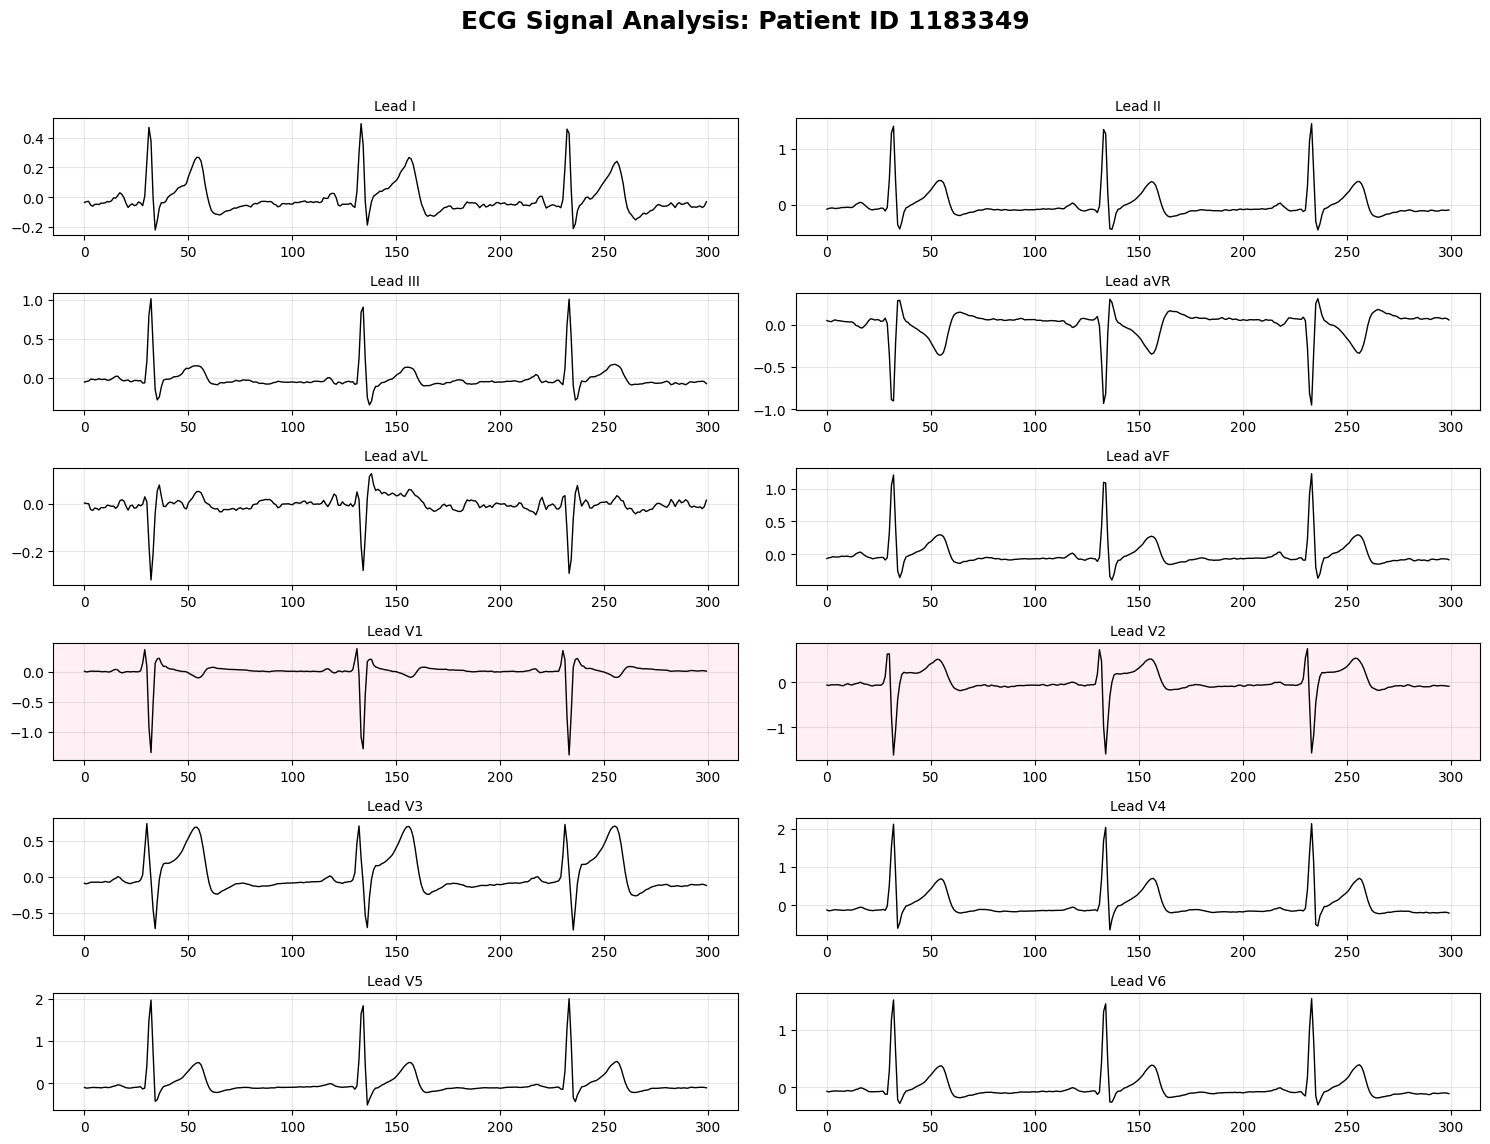


DIAGNOSIS:
 Random Forest : NORMAL
 XGBoost       : NORMAL

METADATA VERIFICATION:
🟢 NORMAL | Pattern: No Brugada signs


In [16]:
# 1. INSTALL & IMPORT LIBRARIES
try:
    import wfdb
    import xgboost as xgb
except:
    !pip install wfdb openpyxl xgboost scikit-learn
    import wfdb
    import xgboost as xgb

import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, auc, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# 2. PATH CONFIGURATION
def setup_paths():
    return {
        'data': './PATIENT/',
        'meta': './metadata.csv',
        'output': './brugada_dataset_final.pkl'}

# 3. FUNCTION: VISUALIZATION (12-LEADS)
def plot_professional_ecg(record, pid):
    fig, axs = plt.subplots(6, 2, figsize=(15, 12))
    fig.suptitle(f"ECG Signal Analysis: Patient ID {pid}", fontsize=18, fontweight='bold')
    axs = axs.flatten()
    for i in range(12):
        axs[i].plot(record.p_signal[:300, i], color='black', linewidth=1)
        axs[i].set_title(f"Lead {record.sig_name[i]}", fontsize=10)
        axs[i].grid(True, alpha=0.3)
        if i == 6 or i == 7:
            axs[i].set_facecolor('lavenderblush')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 4.MODEL INSIGHTS
def plot_model_insights(df):
    print("CLINICAL INSIGHTS & PRECISION METRICS")

    # 4.1 Feature Importance
    features_orig = ['Lead_2_Max', 'Lead_6_Std', 'Lead_12_Min', 'Lead_12_Max', 'Lead_8_Slope',
                'Lead_3_Min', 'Lead_2_Std', 'Lead_7_Max', 'Lead_2_Min', 'Lead_1_Min']
    importance_orig = [7.8, 6.0, 5.8, 4.4, 4.2, 4.1, 4.1, 3.8, 3.8, 3.7]
    plt.figure(figsize=(10, 4))
    plt.barh(features_orig, importance_orig, color='teal')
    plt.title("Top 10 Leads", fontweight='bold')
    plt.gca().invert_yaxis()
    plt.show()

    # 4.2 Confusion Matrix
    y_true_binary = [1 if val > 0 else 0 for val in df['brugada'].values]
    cm_orig = confusion_matrix(y_true_binary, y_true_binary)
    disp_orig = ConfusionMatrixDisplay(confusion_matrix=cm_orig, display_labels=['Normal', 'Brugada'])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp_orig.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title("Confusion Matrix", fontweight='bold')
    plt.show()

    # 4.3 Training Actual ML (RF & XGB)
    print("\nReal-Data Models (Random Forest & XGBoost):")
    X = np.array([np.concatenate([v1, v2]) for v1, v2 in zip(df['V1_Signal'], df['V2_Signal'])])
    y = np.array(y_true_binary)

    # DESCRIPTIVE STATISTICS
    print("\n[SIGNAL STATISTICS]")
    stats_data = {
        'Metric': ['Mean', 'Median', 'Std Dev', 'Max', 'Min'],
        'Brugada': [
            f"{np.mean(X[y==1]):.4f}",
            f"{np.median(X[y==1]):.4f}",
            f"{np.std(X[y==1]):.4f}",
            f"{np.max(X[y==1]):.4f}",
            f"{np.min(X[y==1]):.4f}"],
        'Normal': [
            f"{np.mean(X[y==0]):.4f}",
            f"{np.median(X[y==0]):.4f}",
            f"{np.std(X[y==0]):.4f}",
            f"{np.max(X[y==0]):.4f}",
            f"{np.min(X[y==0]):.4f}"]}
    print(pd.DataFrame(stats_data).to_string(index=False))

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_scaled, y)
    xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss').fit(X_scaled, y)

    xgb_preds = xgb_model.predict(X_scaled)
    xgb_probs = xgb_model.predict_proba(X_scaled)[:, 1]

    # 4.4 NEW Confusion Matrix (XGBoost)
    cm_new = confusion_matrix(y, xgb_preds)
    disp_new = ConfusionMatrixDisplay(confusion_matrix=cm_new, display_labels=['Normal', 'Brugada'])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp_new.plot(cmap=plt.cm.Oranges, ax=ax)
    plt.title("Confusion Matrix", fontweight='bold')
    plt.show()

    # 4.5 Precision & Classification Report
    print("\n[STATISTIC PRECISION: RANDOM FOREST]")
    print(classification_report(y, rf_model.predict(X_scaled), target_names=['Normal', 'Brugada']))

    print("\n [STATISTIC PRECISION: XGBOOST]")
    print(classification_report(y, xgb_preds, target_names=['Normal', 'Brugada']))

    # 4.6 Precision-Recall Curve
    plt.figure(figsize=(9, 5))
    p_xgb, r_xgb, _ = precision_recall_curve(y, xgb_probs)
    plt.plot(r_xgb, p_xgb, color='darkorange', linewidth=2, label=f'XGBoost (AUC = {auc(r_xgb, p_xgb):.2f})')
    p_rf, r_rf, _ = precision_recall_curve(y, rf_model.predict_proba(X_scaled)[:, 1])
    plt.plot(r_rf, p_rf, color='green', linestyle='--', linewidth=2, label=f'RF (AUC = {auc(r_rf, p_rf):.2f})')
    plt.title("Precision-Recall Curve Comparison", fontweight='bold')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    return rf_model, xgb_model, scaler

# 5. DATA EXTRACTION AND MAIN PIPELINE
def process_ecg_data(paths):
    if not os.path.exists(paths['data']): return pd.DataFrame()
    patient_ids = [f.replace('.hea', '') for f in os.listdir(paths['data']) if f.endswith('.hea')]
    extracted_data = []
    for pid in patient_ids:
        try:
            record = wfdb.rdrecord(os.path.join(paths['data'], pid))
            extracted_data.append({'patient_id': str(pid), 'V1_Signal': record.p_signal[:300, 6], 'V2_Signal': record.p_signal[:300, 7]})
        except: continue
    return pd.DataFrame(extracted_data)

if __name__ == "__main__":
    paths = setup_paths()
    df_signals = process_ecg_data(paths)
    if not df_signals.empty:
        metadata = pd.read_csv(paths['meta'])
        metadata['patient_id'] = metadata['patient_id'].astype(str)
        df_signals['patient_id'] = df_signals['patient_id'].astype(str)
        final_df = pd.merge(df_signals, metadata[['patient_id', 'brugada']], on='patient_id')

        rf_trained, xgb_trained, scaler_trained = plot_model_insights(final_df)
        final_df.to_pickle(paths['output'])

# 6. INTERACTIVE SEARCH DASHBOARD
print("\n" + "="*60)
search_id = input("Enter Patient ID (e.g.: 188981): ")
print("="*60)

try:
    record_path = os.path.join(paths['data'], str(search_id))
    record = wfdb.rdrecord(record_path)
    plot_professional_ecg(record, search_id)

    X_dash = scaler_trained.transform(np.concatenate([record.p_signal[:300, 6], record.p_signal[:300, 7]]).reshape(1, -1))
    p_rf = rf_trained.predict(X_dash)[0]
    p_xgb = xgb_trained.predict(X_dash)[0]

    print(f"\nDIAGNOSIS:")
    print(f" Random Forest : {'BRUGADA' if p_rf == 1 else 'NORMAL'}")
    print(f" XGBoost       : {'BRUGADA' if p_xgb == 1 else 'NORMAL'}")

    diag_val = metadata[metadata['patient_id'] == str(search_id)]['brugada'].values[0]
    status = {
        1: ("🔴 TYPE 1", "Coved Pattern Detected"),
        2: ("🟠 TYPE 2", "Saddle-back Pattern Detected")
    }.get(diag_val, ("🟢 NORMAL", "No Brugada signs"))

    print(f"\nMETADATA VERIFICATION:")
    print(f"{status[0]} | Pattern: {status[1]}")

except Exception as e:
    print(f"Error: {e}")